# Federated Phishing Email Detection — Results Analysis
**Abbineshkar Loganathan (25248174) | MSc Adaptive Cybersecurity | University of Galway**

This notebook loads all experiment results and produces:
1. Summary metrics table (Table I in paper)
2. Per-round F1 convergence plots (FedAvg vs FedProx)
3. Non-IID condition comparison heatmap
4. FedProx µ sensitivity analysis
5. DistilBERT vs TinyBERT comparison
6. Vocabulary overlap heatmap (feature skew validation)
7. Convergence speed comparison bar chart

In [13]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':    150,
    'font.family':   'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':     True,
    'grid.alpha':    0.3,
})
PALETTE = {
    'fedavg':  '#2563EB',   # blue
    'fedprox': '#DC2626',   # red
    'distilbert': '#7C3AED', # purple
    'tinybert':   '#D97706', # amber
}

RESULTS_DIR = '../results'
FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup complete')

Setup complete


## 1. Load All Results

In [14]:
# ── Final metrics summary ──────────────────────────────────────────────────
summary_path = os.path.join(RESULTS_DIR, 'all_experiments_summary.csv')

if os.path.exists(summary_path):
    summary = pd.read_csv(summary_path)
    print(f'Loaded {len(summary)} experiments from summary CSV')
else:
    # Build from individual JSON files if summary doesn't exist yet
    records = []
    for path in glob.glob(os.path.join(RESULTS_DIR, '*_final.json')):
        with open(path) as f:
            records.append(json.load(f))
    summary = pd.DataFrame(records)
    print(f'Built summary from {len(summary)} JSON files')

# ── Per-round data ─────────────────────────────────────────────────────────
round_dfs = {}
for path in glob.glob(os.path.join(RESULTS_DIR, '*_rounds.csv')):
    exp_id = os.path.basename(path).replace('_rounds.csv', '')
    if '_mu' not in exp_id:   # exclude µ-sweep variants for main plots
        round_dfs[exp_id] = pd.read_csv(path)

print(f'Loaded round data for: {sorted(round_dfs.keys())}')
summary

Loaded 20 experiments from summary CSV
Loaded round data for: ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']


,experiment_id,model,aggregation,non_iid_type,alpha,mu,accuracy,f1,precision,recall,auc_roc,loss,convergence_round,total_rounds,runtime_sec
0,E1,distilbert,fedavg,label_skew_iid,100.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1,6,963.9
1,E2,distilbert,fedavg,label_skew_moderate,0.5,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1,6,992.6
2,E3,distilbert,fedavg,label_skew_severe,0.1,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.964312e-08,2,7,1140.3
3,E4,distilbert,fedavg,feature_skew,NaN,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,1,6,983.1
4,E5,distilbert,fedprox,label_skew_iid,NaN,0.1,1.000000,1.000000,1.000000,1.000000,1.000000,1.483271e-04,1,6,1714.1
5,E6,distilbert,fedprox,label_skew_moderate,NaN,0.1,1.000000,1.000000,1.000000,1.000000,1.000000,7.076605e-05,2,7,1912.3
6,E7,distilbert,fedprox,label_skew_severe,NaN,0.1,1.000000,1.000000,1.000000,1.000000,1.000000,1.223627e-04,4,9,2293.3
7,E8,distilbert,fedprox,feature_skew,NaN,0.1,1.000000,1.000000,1.000000,1.000000,1.000000,8.441785e-05,1,6,1268.2
8,E9,tinybert,fedavg,label_skew_iid,100.0,0.0,0.999279,0.999279,0.999281,0.999278,1.000000,1.130304e-02,3,8,593.2
9,E10,tinybert,fedavg,label_skew_moderate,0.5,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.192093e-07,1,6,418.2


## 2. Summary Metrics Table

In [15]:
display_cols = ['experiment_id', 'model', 'aggregation', 'non_iid_type',
                'accuracy', 'f1', 'precision', 'recall', 'auc_roc', 'convergence_round']

table = summary[display_cols].copy()
table['non_iid_type'] = table['non_iid_type'].str.replace('_', ' ').str.title()

# Format floats
for col in ['accuracy', 'f1', 'precision', 'recall', 'auc_roc']:
    if col in table.columns:
        table[col] = table[col].map('{:.4f}'.format)

print('=== FULL RESULTS TABLE ===')
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 120)
display(table)

=== FULL RESULTS TABLE ===


,experiment_id,model,aggregation,non_iid_type,accuracy,f1,precision,recall,auc_roc,convergence_round
0,E1,distilbert,fedavg,Label Skew Iid,1.0000,1.0000,1.0000,1.0000,1.0000,1
1,E2,distilbert,fedavg,Label Skew Moderate,1.0000,1.0000,1.0000,1.0000,1.0000,1
2,E3,distilbert,fedavg,Label Skew Severe,1.0000,1.0000,1.0000,1.0000,1.0000,2
3,E4,distilbert,fedavg,Feature Skew,1.0000,1.0000,1.0000,1.0000,1.0000,1
4,E5,distilbert,fedprox,Label Skew Iid,1.0000,1.0000,1.0000,1.0000,1.0000,1
5,E6,distilbert,fedprox,Label Skew Moderate,1.0000,1.0000,1.0000,1.0000,1.0000,2
6,E7,distilbert,fedprox,Label Skew Severe,1.0000,1.0000,1.0000,1.0000,1.0000,4
7,E8,distilbert,fedprox,Feature Skew,1.0000,1.0000,1.0000,1.0000,1.0000,1
8,E9,tinybert,fedavg,Label Skew Iid,0.9993,0.9993,0.9993,0.9993,1.0000,3
9,E10,tinybert,fedavg,Label Skew Moderate,1.0000,1.0000,1.0000,1.0000,1.0000,1


## 3. F1 Convergence Curves — FedAvg vs FedProx

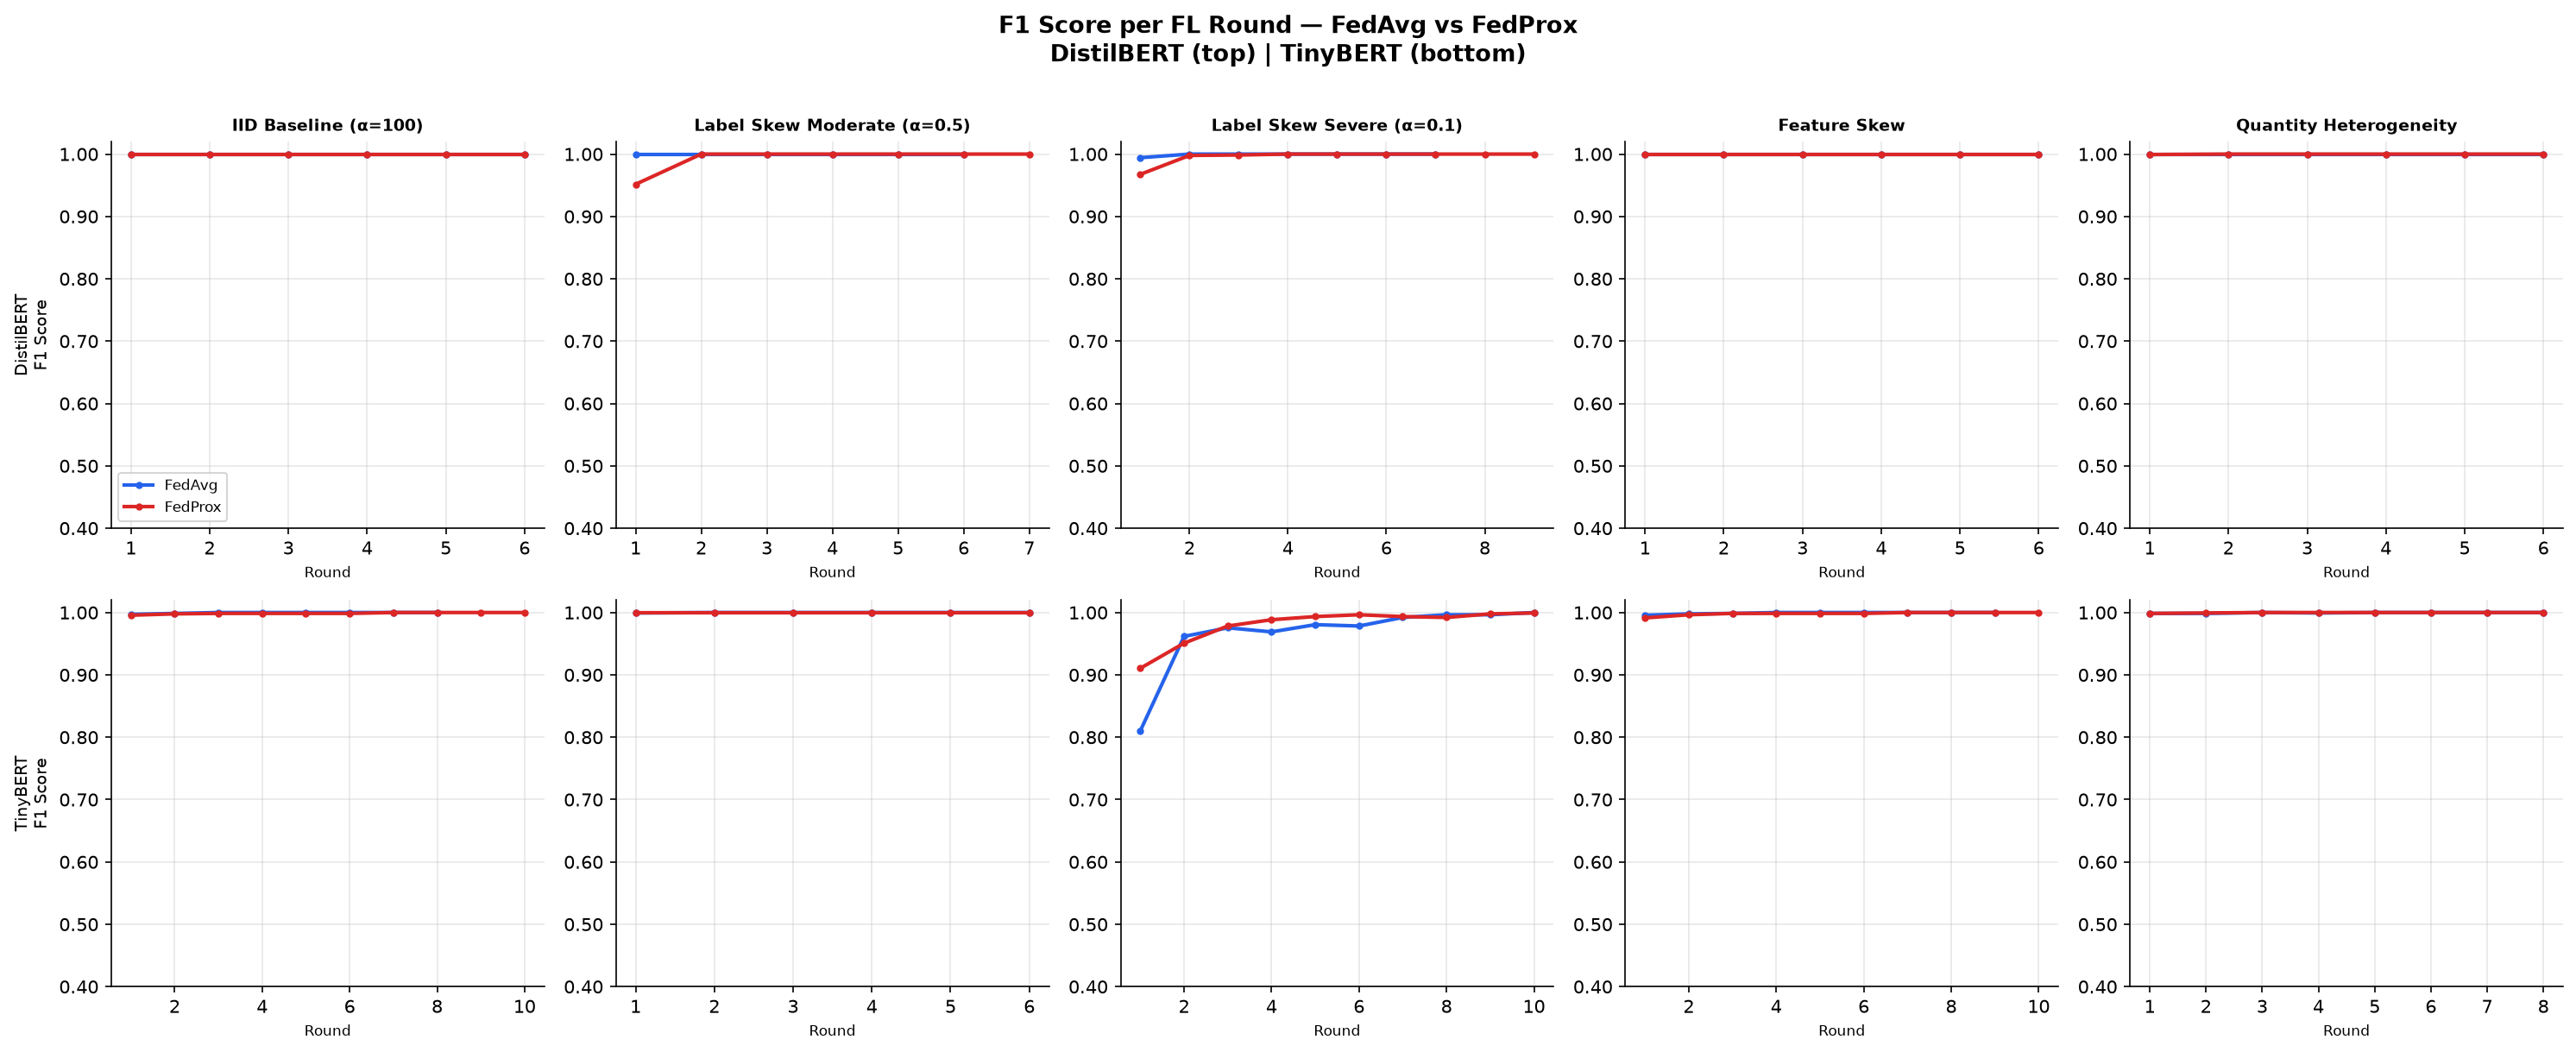

Saved: convergence_curves.pdf


In [16]:
non_iid_types = [
    ('label_skew_iid',      'IID Baseline (α=100)'),
    ('label_skew_moderate', 'Label Skew Moderate (α=0.5)'),
    ('label_skew_severe',   'Label Skew Severe (α=0.1)'),
    ('feature_skew',        'Feature Skew'),
    ('quantity',            'Quantity Heterogeneity'),
]
models = [('distilbert', 'DistilBERT'), ('tinybert', 'TinyBERT')]

fig, axes = plt.subplots(len(models), len(non_iid_types),
                          figsize=(20, 8), sharey=False)

for row, (model_key, model_name) in enumerate(models):
    for col, (nid_type, nid_label) in enumerate(non_iid_types):
        ax = axes[row, col]

        for agg, agg_label in [('fedavg', 'FedAvg'), ('fedprox', 'FedProx')]:
            # Find matching experiment
            match = summary[
                (summary['model'] == model_key) &
                (summary['aggregation'] == agg) &
                (summary['non_iid_type'] == nid_type)
            ]
            if match.empty:
                continue

            exp_id = match.iloc[0]['experiment_id']
            if exp_id not in round_dfs:
                continue

            rdf = round_dfs[exp_id]
            ax.plot(
                rdf['round'], rdf['f1'],
                color=PALETTE[agg],
                label=agg_label,
                linewidth=2,
                marker='o', markersize=3,
            )

        if row == 0:
            ax.set_title(nid_label, fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{model_name}\nF1 Score', fontsize=9)
        ax.set_xlabel('Round', fontsize=8)
        ax.set_ylim(0.4, 1.02)
        ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

        if row == 0 and col == 0:
            ax.legend(fontsize=8)

plt.suptitle('F1 Score per FL Round — FedAvg vs FedProx\nDistilBERT (top) | TinyBERT (bottom)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'convergence_curves.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(FIGURES_DIR, 'convergence_curves.png'), bbox_inches='tight')
plt.show()
print('Saved: convergence_curves.pdf')

## 4. Non-IID Accuracy Degradation Heatmap

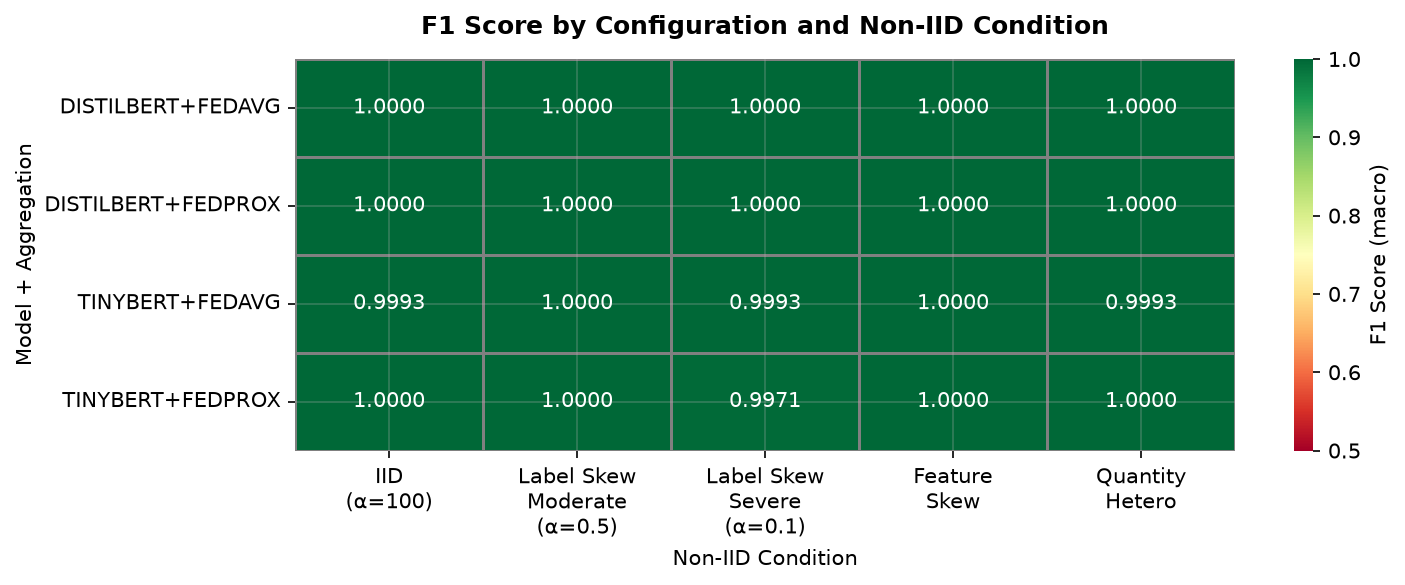

Saved: heatmap_f1.pdf


In [17]:
# Pivot: rows = model+aggregation, cols = non_iid_type
if not summary.empty and 'f1' in summary.columns:
    pivot_df = summary.copy()
    pivot_df['config'] = pivot_df['model'].str.upper() + '+' + pivot_df['aggregation'].str.upper()
    pivot_df['f1'] = pd.to_numeric(pivot_df['f1'], errors='coerce')

    pivot = pivot_df.pivot_table(
        index='config', columns='non_iid_type', values='f1', aggfunc='mean'
    )

    # Reorder columns
    col_order = ['label_skew_iid', 'label_skew_moderate', 'label_skew_severe',
                 'feature_skew', 'quantity']
    col_order = [c for c in col_order if c in pivot.columns]
    pivot = pivot[col_order]

    col_labels = {
        'label_skew_iid':      'IID\n(α=100)',
        'label_skew_moderate': 'Label Skew\nModerate\n(α=0.5)',
        'label_skew_severe':   'Label Skew\nSevere\n(α=0.1)',
        'feature_skew':        'Feature\nSkew',
        'quantity':            'Quantity\nHetero',
    }
    pivot.columns = [col_labels.get(c, c) for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap='RdYlGn',
        vmin=0.5, vmax=1.0,
        linewidths=0.5, linecolor='grey',
        ax=ax, cbar_kws={'label': 'F1 Score (macro)'}
    )
    ax.set_title('F1 Score by Configuration and Non-IID Condition',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Non-IID Condition', fontsize=10)
    ax.set_ylabel('Model + Aggregation', fontsize=10)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'heatmap_f1.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, 'heatmap_f1.png'), bbox_inches='tight')
    plt.show()
    print('Saved: heatmap_f1.pdf')

## 5. FedProx µ Sensitivity Analysis

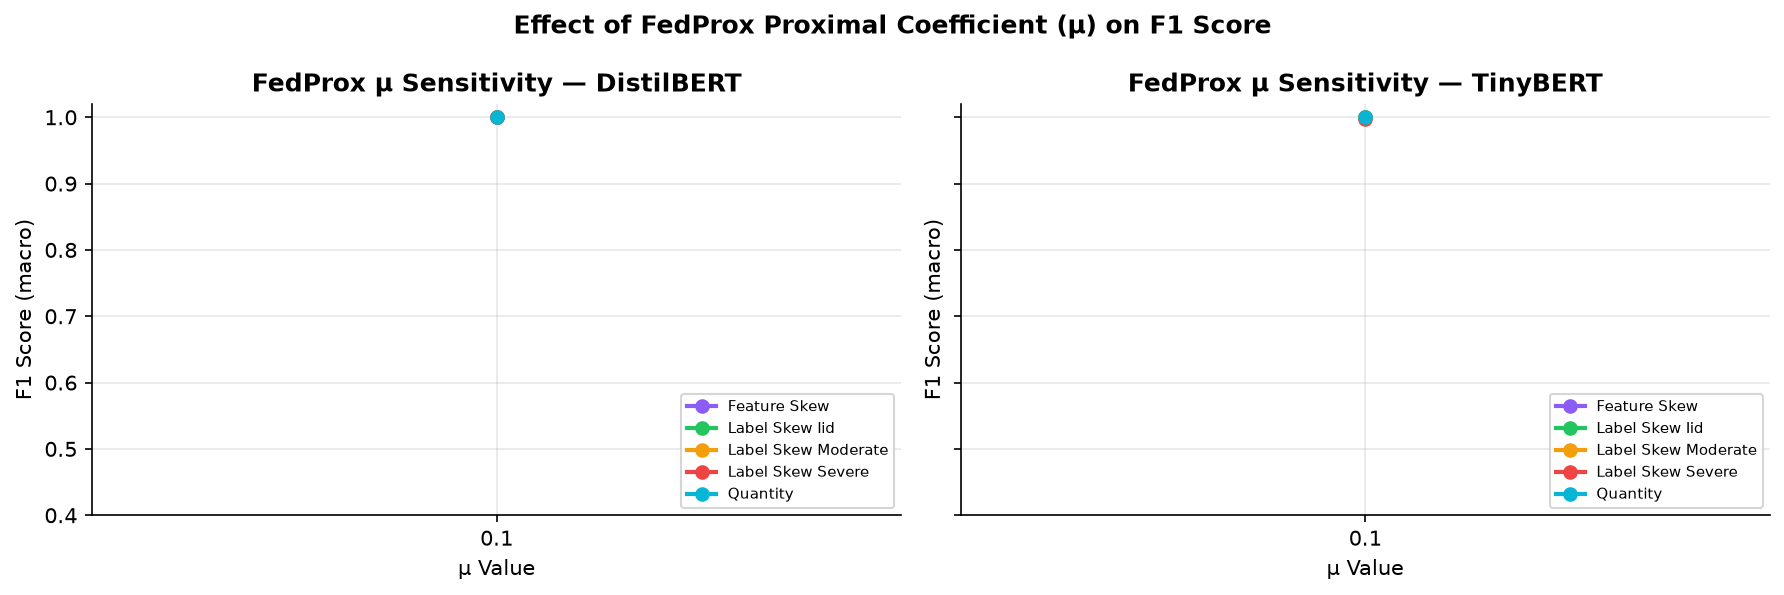

Saved: mu_sensitivity.pdf


In [18]:
# Load µ-sweep results
mu_records = []
for path in glob.glob(os.path.join(RESULTS_DIR, '*_mu*_final.json')):
    with open(path) as f:
        mu_records.append(json.load(f))

# Also include primary µ=0.1 results from main matrix
for path in glob.glob(os.path.join(RESULTS_DIR, 'E*_final.json')):
    with open(path) as f:
        r = json.load(f)
    if r.get('aggregation') == 'fedprox':
        mu_records.append(r)

if mu_records:
    mu_df = pd.DataFrame(mu_records)
    mu_df['f1']  = pd.to_numeric(mu_df['f1'],  errors='coerce')
    mu_df['mu']  = pd.to_numeric(mu_df['mu'],  errors='coerce')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, (model_key, model_name) in zip(axes, [('distilbert', 'DistilBERT'),
                                                    ('tinybert',   'TinyBERT')]):
        sub = mu_df[mu_df['model'] == model_key].copy()
        if sub.empty:
            ax.set_title(f'{model_name} — no µ sweep data')
            continue

        nid_palette = {
            'label_skew_iid':      '#22C55E',
            'label_skew_moderate': '#F59E0B',
            'label_skew_severe':   '#EF4444',
            'feature_skew':        '#8B5CF6',
            'quantity':            '#06B6D4',
        }

        for nid_type, grp in sub.groupby('non_iid_type'):
            grp_sorted = grp.sort_values('mu')
            ax.plot(
                grp_sorted['mu'].astype(str),
                grp_sorted['f1'],
                marker='o', linewidth=2,
                color=nid_palette.get(nid_type, 'grey'),
                label=nid_type.replace('_', ' ').title()
            )

        ax.set_title(f'FedProx µ Sensitivity — {model_name}', fontweight='bold')
        ax.set_xlabel('µ Value')
        ax.set_ylabel('F1 Score (macro)')
        ax.set_ylim(0.4, 1.02)
        ax.legend(fontsize=7, loc='lower right')

    plt.suptitle('Effect of FedProx Proximal Coefficient (µ) on F1 Score',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'mu_sensitivity.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, 'mu_sensitivity.png'), bbox_inches='tight')
    plt.show()
    print('Saved: mu_sensitivity.pdf')
else:
    print('No µ sweep data found. Run with --mu_sweep to generate.')

## 6. DistilBERT vs TinyBERT Comparison

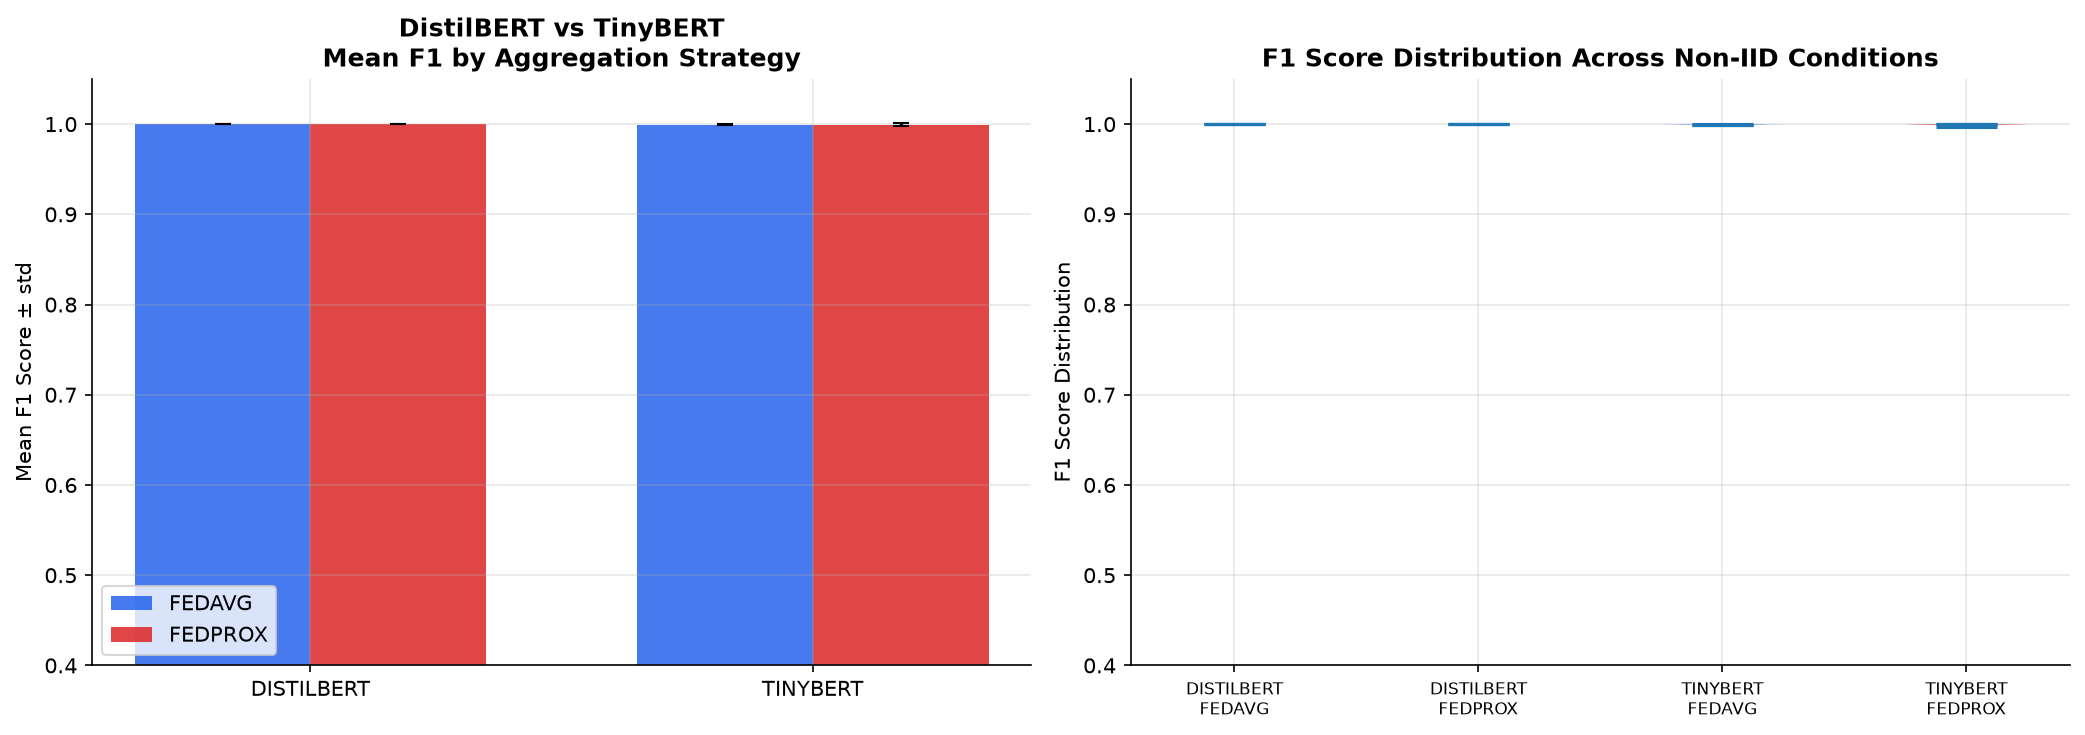

Saved: model_comparison.pdf


In [19]:
if not summary.empty:
    df_plot = summary.copy()
    df_plot['f1'] = pd.to_numeric(df_plot['f1'], errors='coerce')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── F1 by model and aggregation ──
    ax = axes[0]
    grp = df_plot.groupby(['model', 'aggregation'])['f1'].agg(['mean', 'std']).reset_index()
    x   = np.arange(len(grp['model'].unique()))
    width = 0.35
    model_names = grp['model'].unique()

    for i, agg in enumerate(['fedavg', 'fedprox']):
        sub = grp[grp['aggregation'] == agg]
        means = [sub[sub['model'] == m]['mean'].values[0] if m in sub['model'].values else 0
                 for m in model_names]
        stds  = [sub[sub['model'] == m]['std'].values[0]  if m in sub['model'].values else 0
                 for m in model_names]
        ax.bar(
            x + i*width - width/2, means,
            width=width, label=agg.upper(),
            color=PALETTE[agg], alpha=0.85,
            yerr=stds, capsize=4, error_kw={'linewidth': 1.5}
        )

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in model_names], fontsize=10)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('Mean F1 Score ± std')
    ax.set_title('DistilBERT vs TinyBERT\nMean F1 by Aggregation Strategy', fontweight='bold')
    ax.legend()

    # ── F1 distribution violin ──
    ax = axes[1]
    df_violin = df_plot[['model', 'aggregation', 'f1']].dropna()
    df_violin['group'] = df_violin['model'].str.upper() + '\n' + df_violin['aggregation'].str.upper()
    order = ['DISTILBERT\nFEDAVG', 'DISTILBERT\nFEDPROX',
             'TINYBERT\nFEDAVG',   'TINYBERT\nFEDPROX']
    order = [o for o in order if o in df_violin['group'].unique()]

    colors = [PALETTE['fedavg'], PALETTE['fedprox'],
              PALETTE['fedavg'], PALETTE['fedprox']]

    violin_parts = ax.violinplot(
        [df_violin[df_violin['group'] == g]['f1'].values for g in order],
        positions=range(len(order)),
        showmedians=True,
    )
    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(colors[i % len(colors)])
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=8)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('F1 Score Distribution')
    ax.set_title('F1 Score Distribution Across Non-IID Conditions', fontweight='bold')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'model_comparison.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, 'model_comparison.png'), bbox_inches='tight')
    plt.show()
    print('Saved: model_comparison.pdf')

## 7. Convergence Speed Comparison

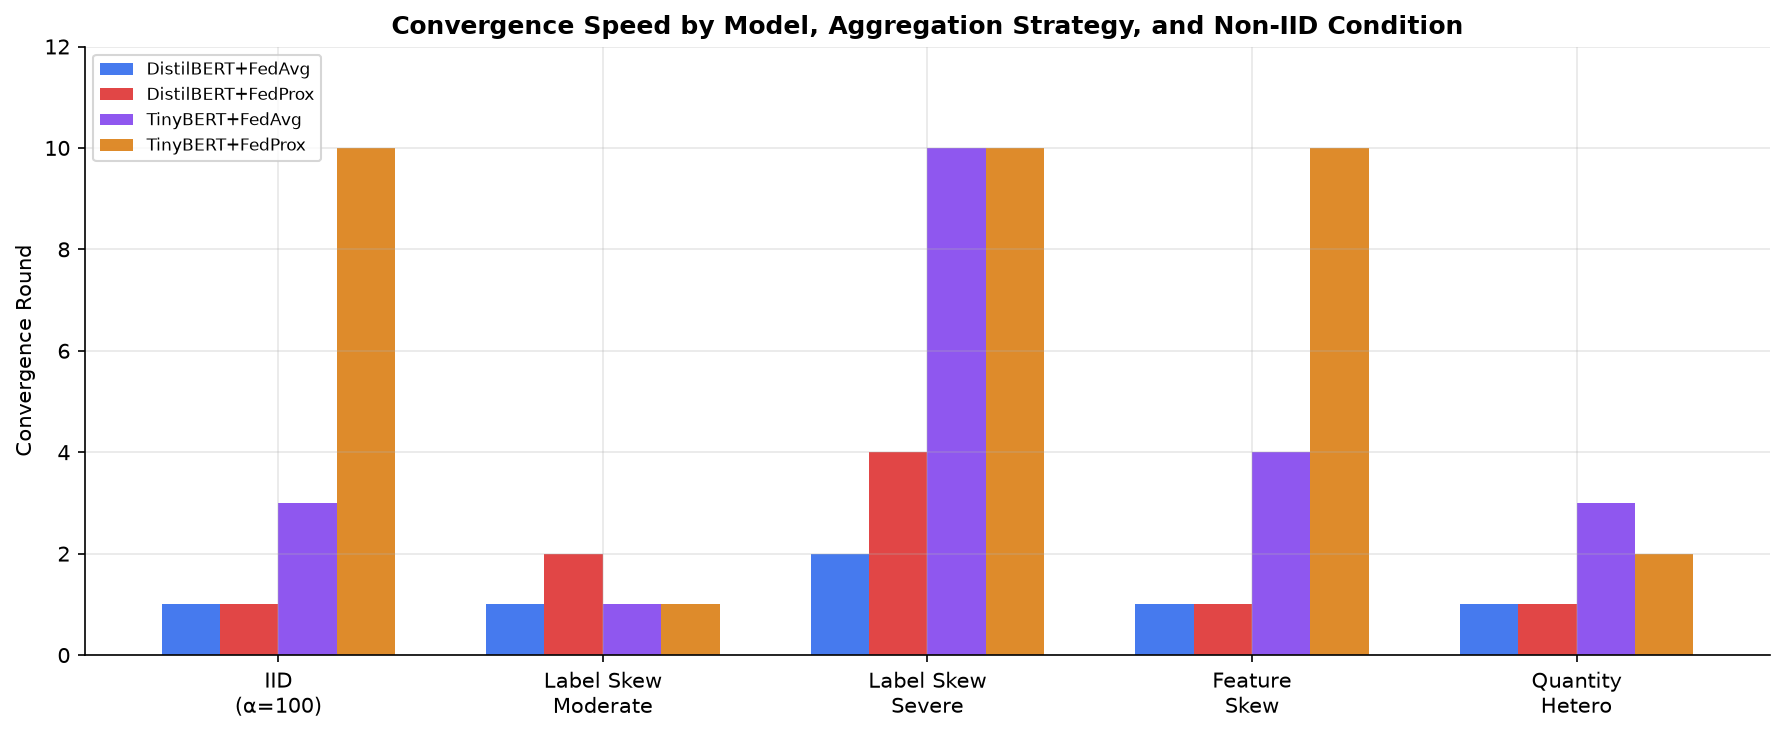

Saved: convergence_speed.pdf


In [20]:
if not summary.empty and 'convergence_round' in summary.columns:
    df_conv = summary.copy()
    df_conv['convergence_round'] = pd.to_numeric(df_conv['convergence_round'], errors='coerce')

    fig, ax = plt.subplots(figsize=(12, 5))

    nid_order = ['label_skew_iid', 'label_skew_moderate', 'label_skew_severe',
                 'feature_skew', 'quantity']
    nid_labels = ['IID\n(α=100)', 'Label Skew\nModerate', 'Label Skew\nSevere',
                  'Feature\nSkew', 'Quantity\nHetero']

    x = np.arange(len(nid_order))
    width = 0.18

    configs = [
        ('distilbert', 'fedavg',  'DistilBERT+FedAvg',  PALETTE['fedavg'],  -1.5),
        ('distilbert', 'fedprox', 'DistilBERT+FedProx', PALETTE['fedprox'], -0.5),
        ('tinybert',   'fedavg',  'TinyBERT+FedAvg',    PALETTE['distilbert'], 0.5),
        ('tinybert',   'fedprox', 'TinyBERT+FedProx',   PALETTE['tinybert'],   1.5),
    ]

    for model_key, agg, label, color, offset in configs:
        vals = []
        for nid in nid_order:
            m = df_conv[(df_conv['model']==model_key) &
                        (df_conv['aggregation']==agg) &
                        (df_conv['non_iid_type']==nid)]
            vals.append(m['convergence_round'].mean() if not m.empty else np.nan)

        ax.bar(
            x + offset * width, vals,
            width=width, label=label,
            color=color, alpha=0.85,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(nid_labels)
    ax.set_ylabel('Convergence Round')
    ax.set_title('Convergence Speed by Model, Aggregation Strategy, and Non-IID Condition',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, max(df_conv['convergence_round'].max() * 1.2, 5))

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'convergence_speed.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, 'convergence_speed.png'), bbox_inches='tight')
    plt.show()
    print('Saved: convergence_speed.pdf')

## 8. Vocabulary Overlap Heatmap (Feature Skew Validation)

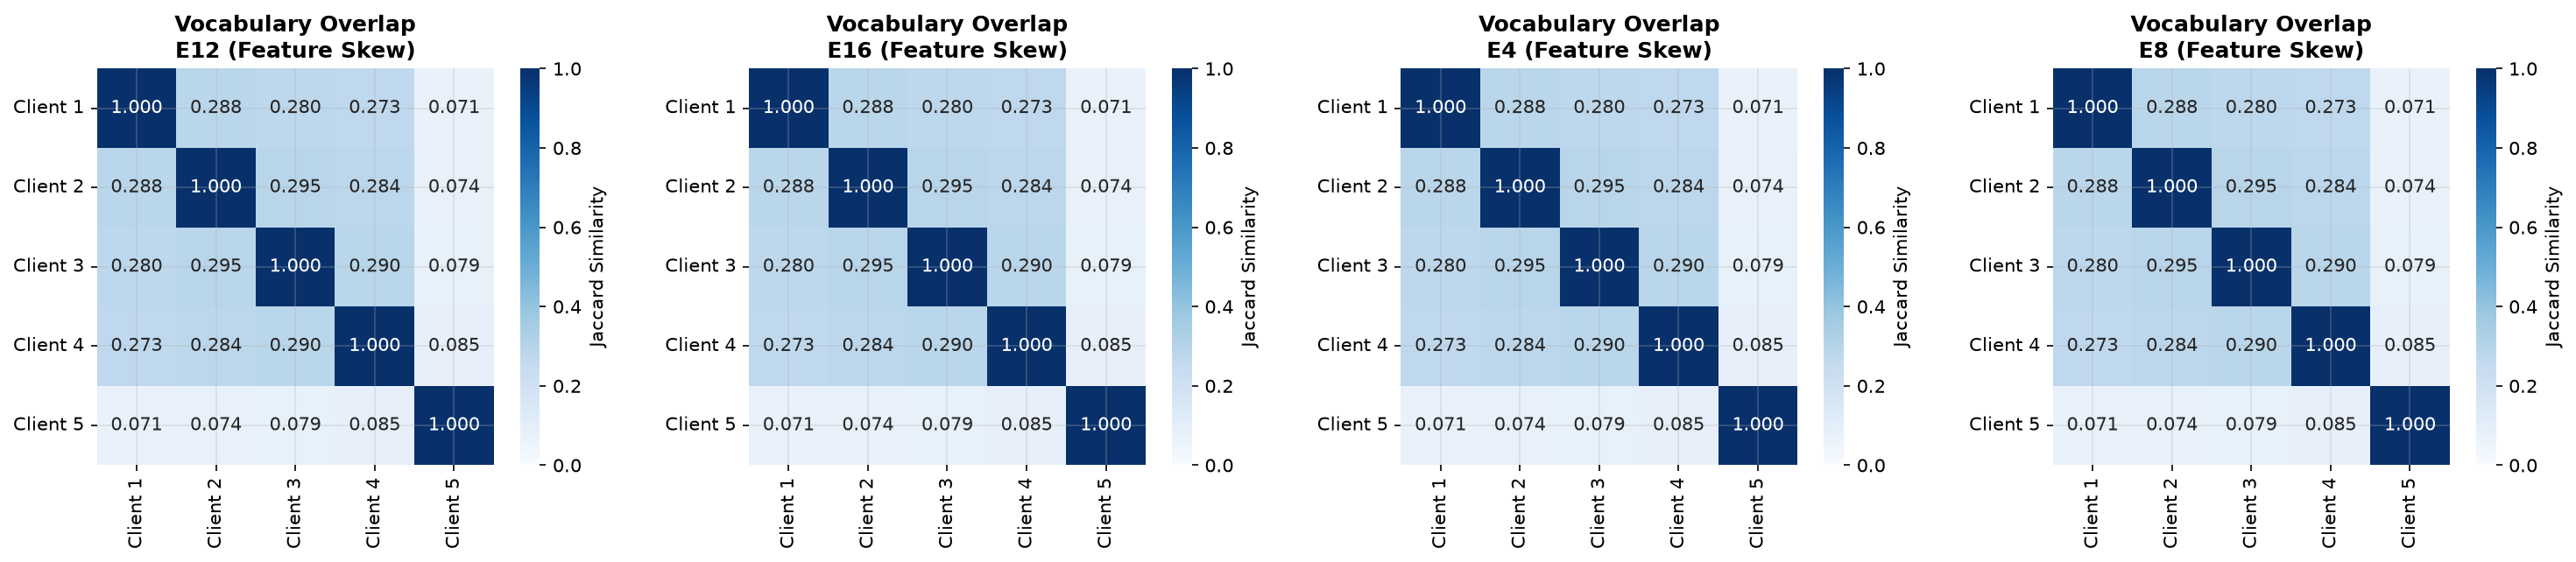

Saved: vocab_overlap.pdf


In [21]:
# Load any saved vocab overlap CSV
overlap_paths = glob.glob(os.path.join(RESULTS_DIR, '*_vocab_overlap.csv'))

if overlap_paths:
    fig, axes = plt.subplots(1, len(overlap_paths),
                              figsize=(5 * len(overlap_paths), 4))
    if len(overlap_paths) == 1:
        axes = [axes]

    for ax, path in zip(axes, overlap_paths):
        exp_id = os.path.basename(path).replace('_vocab_overlap.csv', '')
        df_ov  = pd.read_csv(path, index_col=0)

        sns.heatmap(
            df_ov, annot=True, fmt='.3f',
            cmap='Blues', vmin=0, vmax=1,
            ax=ax, square=True,
            cbar_kws={'label': 'Jaccard Similarity'},
        )
        ax.set_title(f'Vocabulary Overlap\n{exp_id} (Feature Skew)',
                     fontweight='bold')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'vocab_overlap.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, 'vocab_overlap.png'), bbox_inches='tight')
    plt.show()
    print('Saved: vocab_overlap.pdf')
else:
    print('No vocabulary overlap files found.')

## 9. Statistical Tests — FedAvg vs FedProx

In [22]:
# Paired Wilcoxon signed-rank test: do FedProx F1 scores significantly differ from FedAvg?
from scipy.stats import wilcoxon, ttest_rel

if not summary.empty:
    df_stat = summary.copy()
    df_stat['f1'] = pd.to_numeric(df_stat['f1'], errors='coerce')

    # Only Non-IID conditions (exclude IID baseline)
    non_iid_mask = df_stat['non_iid_type'] != 'label_skew_iid'

    print('=== Statistical Tests: FedAvg vs FedProx (Non-IID conditions only) ===')
    for model_key in ['distilbert', 'tinybert']:
        fedavg_f1  = df_stat[(df_stat['model']==model_key) &
                              (df_stat['aggregation']=='fedavg') &
                              non_iid_mask]['f1'].dropna().values
        fedprox_f1 = df_stat[(df_stat['model']==model_key) &
                              (df_stat['aggregation']=='fedprox') &
                              non_iid_mask]['f1'].dropna().values

        n = min(len(fedavg_f1), len(fedprox_f1))
        if n < 2:
            print(f'{model_key.upper()}: insufficient data (n={n})')
            continue

        fedavg_f1  = fedavg_f1[:n]
        fedprox_f1 = fedprox_f1[:n]

        try:
            stat, p_wlcx = wilcoxon(fedavg_f1, fedprox_f1)
            t_stat, p_t  = ttest_rel(fedavg_f1, fedprox_f1)
        except Exception as e:
            print(f'{model_key.upper()}: test failed — {e}')
            continue

        delta = np.mean(fedprox_f1) - np.mean(fedavg_f1)
        direction = 'FedProx better' if delta > 0 else 'FedAvg better'

        print(f'\n{model_key.upper()} (n={n})')
        print(f'  FedAvg  mean F1: {np.mean(fedavg_f1):.4f} ± {np.std(fedavg_f1):.4f}')
        print(f'  FedProx mean F1: {np.mean(fedprox_f1):.4f} ± {np.std(fedprox_f1):.4f}')
        print(f'  Δ F1 (FedProx−FedAvg): {delta:+.4f}  → {direction}')
        print(f'  Wilcoxon signed-rank: stat={stat:.3f}, p={p_wlcx:.4f} {"*" if p_wlcx<0.05 else "ns"}')
        print(f'  Paired t-test:        t={t_stat:.3f},  p={p_t:.4f} {"*" if p_t<0.05 else "ns"}')

=== Statistical Tests: FedAvg vs FedProx (Non-IID conditions only) ===

DISTILBERT (n=4)
  FedAvg  mean F1: 1.0000 ± 0.0000
  FedProx mean F1: 1.0000 ± 0.0000
  Δ F1 (FedProx−FedAvg): +0.0000  → FedAvg better
  Wilcoxon signed-rank: stat=0.000, p=1.0000 ns
  Paired t-test:        t=nan,  p=nan ns

TINYBERT (n=4)
  FedAvg  mean F1: 0.9996 ± 0.0004
  FedProx mean F1: 0.9993 ± 0.0012
  Δ F1 (FedProx−FedAvg): -0.0004  → FedAvg better
  Wilcoxon signed-rank: stat=1.000, p=1.0000 ns
  Paired t-test:        t=0.577,  p=0.6042 ns


d:\federated_phishing\venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


## 10. Per-Metric Accuracy Degradation Under Non-IID

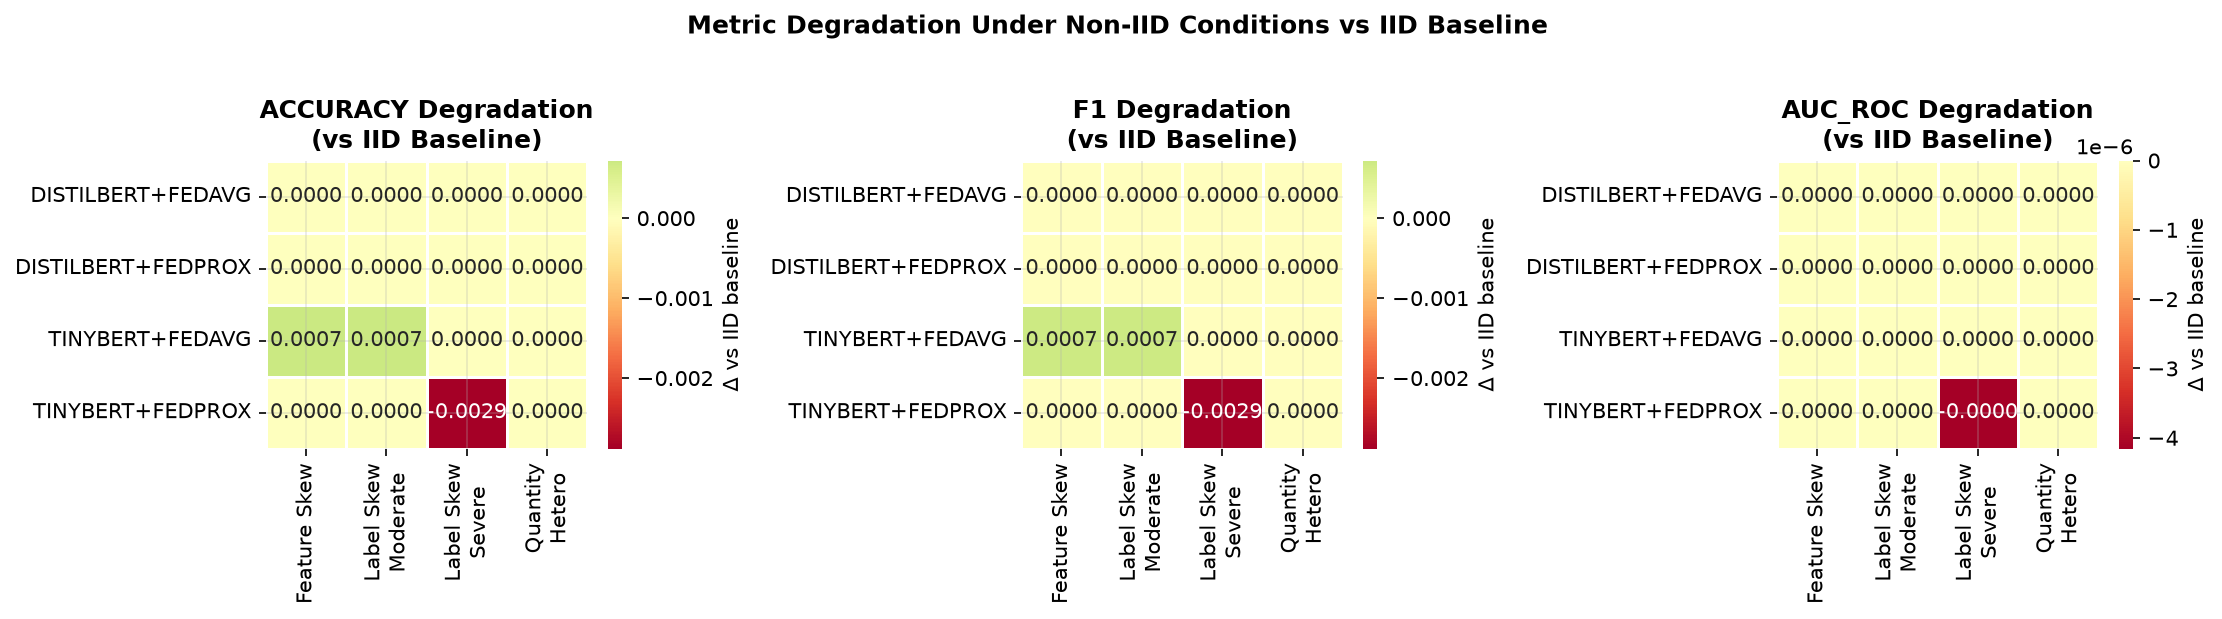

Saved: degradation_heatmap.pdf


In [23]:
if not summary.empty:
    metrics = ['accuracy', 'f1', 'auc_roc']
    df_deg = summary.copy()
    for m in metrics:
        df_deg[m] = pd.to_numeric(df_deg[m], errors='coerce')

    # Compute degradation relative to IID baseline for each model+aggregation config
    records = []
    for model_key in ['distilbert', 'tinybert']:
        for agg in ['fedavg', 'fedprox']:
            iid_row = df_deg[
                (df_deg['model']==model_key) &
                (df_deg['aggregation']==agg) &
                (df_deg['non_iid_type']=='label_skew_iid')
            ]
            if iid_row.empty:
                continue

            for _, row in df_deg[
                (df_deg['model']==model_key) &
                (df_deg['aggregation']==agg) &
                (df_deg['non_iid_type']!='label_skew_iid')
            ].iterrows():
                rec = {
                    'model': model_key,
                    'aggregation': agg,
                    'non_iid_type': row['non_iid_type'],
                    'config': f"{model_key.upper()}+{agg.upper()}",
                }
                for m in metrics:
                    baseline = iid_row.iloc[0][m]
                    rec[f'{m}_degradation'] = row[m] - baseline
                records.append(rec)

    if records:
        deg_df = pd.DataFrame(records)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        nid_labels = {
            'label_skew_moderate': 'Label Skew\nModerate',
            'label_skew_severe':   'Label Skew\nSevere',
            'feature_skew':        'Feature Skew',
            'quantity':            'Quantity\nHetero',
        }

        for ax, metric in zip(axes, metrics):
            col = f'{metric}_degradation'
            if col not in deg_df.columns:
                continue

            pivot = deg_df.pivot_table(index='config', columns='non_iid_type',
                                        values=col, aggfunc='mean')
            pivot.columns = [nid_labels.get(c, c) for c in pivot.columns]

            sns.heatmap(
                pivot, annot=True, fmt='.4f',
                cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Δ vs IID baseline'}
            )
            ax.set_title(f'{metric.upper()} Degradation\n(vs IID Baseline)',
                         fontweight='bold')
            ax.set_xlabel('')
            ax.set_ylabel('')

        plt.suptitle('Metric Degradation Under Non-IID Conditions vs IID Baseline',
                     fontweight='bold', y=1.02)
        plt.tight_layout()
        fig.savefig(os.path.join(FIGURES_DIR, 'degradation_heatmap.pdf'), bbox_inches='tight')
        fig.savefig(os.path.join(FIGURES_DIR, 'degradation_heatmap.png'), bbox_inches='tight')
        plt.show()
        print('Saved: degradation_heatmap.pdf')
    else:
        print('Not enough experiments completed to compute degradation. Run more experiments first.')

## 11. Export Paper-Ready LaTeX Table

In [24]:
if not summary.empty:
    latex_df = summary[['experiment_id', 'model', 'aggregation', 'non_iid_type',
                         'accuracy', 'f1', 'precision', 'recall', 'auc_roc',
                         'convergence_round']].copy()

    for col in ['accuracy', 'f1', 'precision', 'recall', 'auc_roc']:
        if col in latex_df.columns:
            latex_df[col] = pd.to_numeric(latex_df[col], errors='coerce').map('{:.4f}'.format)

    latex_df.columns = [
        'Exp.', 'Model', 'Aggregation', 'Non-IID Type',
        'Accuracy', 'F1', 'Precision', 'Recall', 'AUC-ROC', 'Conv. Round'
    ]

    latex_str = latex_df.to_latex(
        index=False, escape=True,
        caption='Full results for all 20 federated phishing detection experiments.',
        label='tab:full_results',
        column_format='llllcccccr',
    )

    latex_path = os.path.join(FIGURES_DIR, 'results_table.tex')
    with open(latex_path, 'w') as f:
        f.write(latex_str)

    print(f'LaTeX table saved to {latex_path}')
    print('\nFirst 60 lines:')
    print('\n'.join(latex_str.split('\n')[:20]))

LaTeX table saved to ../results/figures\results_table.tex

First 60 lines:
\begin{table}
\caption{Full results for all 20 federated phishing detection experiments.}
\label{tab:full_results}
\begin{tabular}{llllcccccr}
\toprule
Exp. & Model & Aggregation & Non-IID Type & Accuracy & F1 & Precision & Recall & AUC-ROC & Conv. Round \\
\midrule
E1 & distilbert & fedavg & label\_skew\_iid & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1 \\
E2 & distilbert & fedavg & label\_skew\_moderate & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1 \\
E3 & distilbert & fedavg & label\_skew\_severe & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 2 \\
E4 & distilbert & fedavg & feature\_skew & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1 \\
E5 & distilbert & fedprox & label\_skew\_iid & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1 \\
E6 & distilbert & fedprox & label\_skew\_moderate & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 1.0000 & 2 \\
E7 & distilbert & fedprox & label\_skew\_severe & 1.0000 & 1.0000 & 1.